## **Assignment One Part Two: Data Cleaning and Visualisation**
**Student Name:** Jessica Mawuenam Dellason

**Student Number:** 25215734

This project will be based on [Dublin Rental Property Database](http://mlg.ucd.ie/modules/python/sources/rental/index.html)

Data from the website has been scraped, parsed and saved into 'data.csv' file.
### **Data Cleaning Workflow Overview**
This section outlines the overall approach and reasoning used for data cleaning.

The workflow followed these main steps:
1. Load the saved file into a dataframe
2. Inspect data to find missing columns 
3. Inspect non missing columns
4. Handle missing columns

---
#### **1. Loading the Scraped Data**
This block loads the scraped data from part one saved in the `data.csv` file into a Pandas DataFrame named `dataset` using the `read_csv()` function. The DataFrame structure allows the data to be easily cleaned and analysed. A `try–except` block is used to handle potential file-related errors when attempting to load the dataset.

In [236]:
import pandas as pd

try:
    # Load dataset
    dataset = pd.read_csv("data.csv")

except FileExistsError as e:
    print(e)

# Output dataset 
dataset.head(10)

,Month,Type,Price,Location,Postcode,Bedrooms,Bathrooms,Parking,Garden,Lease Length,Contact
0,January,Apartment,840.0,Dublin City South,Dublin 12,1,2,Yes,No,12.0,Estate Agent
1,January,House,3110.0,Dublin City Nth.,Dublin 1,3,1,Yes,Yes,6.0,Owner
2,January,Apartment,2170.0,Dublin City South,Dublin 2,2,1,No,NaN,12.0,Estate Agent
3,January,House,2580.0,Dublin City Sth.,Dublin 6,3,2,Yes,Yes,12.0,Estate Agent
4,January,Apartment,1810.0,Dublin City North,Dublin 1,1,1,No,No,12.0,Estate Agent
5,January,Apartment,2830.0,Dublin City North,Dublin 1,2,2,No,No,12.0,Estate Agent
6,January,House,3520.0,Dublin City North,Dublin 1,4,2,No,Yes,3.0,Owner
7,January,Apartment,1650.0,Dublin City North,Dublin 1,1,1,No,No,12.0,Estate Agent
8,January,House,3280.0,Dublin City South,Dublin 22,3,2,Yes,Yes,12.0,Owner
9,January,Apartment,830.0,Dublin City South,Dublin 18,1,1,No,NaN,120.0,Estate Agent


---
#### **2. Checking for Missing Values**
This line checks for missing values in the dataset. The `isnull()` function identifies empty or missing entries in each column, and `sum()` counts the total number of missing values per column. This step helps to understand the structure and quality of the data before beginning the cleaning process.

In [237]:
# Check number of empty entries per column
dataset.isnull().sum()

Month             0
Type              0
Price             0
Location          0
Postcode        102
Bedrooms          0
Bathrooms         0
Parking         110
Garden          173
Lease Length     38
Contact           0
dtype: int64

### **Inspecting Non-Missing Columns**

---
#### **3. Inspecting the Month Column**
This step begins the data cleaning process by inspecting the **Month** column. The `unique()` function is used to display all unique values in the column. This helps verify that the months correctly range from **January to December** and ensures there are no unexpected, misspelled, or incorrect entries. Since the output of `unique()` shows the values directly, it is sufficient for validating the data without needing to separately check the data type using `dtypes`.

In [238]:
# Check unique Type values
dataset["Month"].unique()

<StringArray>
[  'January',  'February',     'March',     'April',       'May',      'June',
      'July',    'August', 'September',   'October',  'November',  'December']
Length: 12, dtype: str

---
#### **4. Inspecting the Type Column**
This step performs a similar check for the **Type** column. The `unique()` function is used to display all unique values present in the column. This helps verify that the property types are recorded correctly, ensures there are no unexpected or inconsistent entries, and confirms that the values are stored in the correct format.

In [239]:
# Check unique Type values 
dataset["Type"].unique()

<StringArray>
['Apartment', 'House']
Length: 2, dtype: str

---
#### **5. Checking the Price Column**
This step checks the data type of the **Price** column using `dtypes`. This is done to verify whether the price values are stored as numeric data. 

In [240]:
# Check datatype of Price column
dataset["Price"].dtypes

dtype('float64')

---
#### **6. Inspecting the Location Column**
This step begins by checking the unique values in the **Location** column using `unique()` to identify any inconsistencies in how locations are recorded. Some locations appear with different abbreviations or formatting. The `unique()` output also helps confirm that the values are stored as text.

A dictionary called `universal_location` is created to map these variations to a single standardised format. The `replace()` function is then used to update the dataset so that all location values follow consistent naming.

Finally, `unique()` is run again to confirm that the locations have been successfully standardised.

In [241]:
# Check unique location values
print(f"Location values before cleaning:\n{dataset["Location"].unique()}")

# Standardize location names for consistency
universal_location = {"Dublin City Sth.": 'Dublin City South', 
                      'Dublin City Nth.':'Dublin City North', 
                      'Nth. Co D': 'North County Dublin', 
                      'North  Co Dublin': 'North County Dublin', 
                      'Nth. Co Dublin': 'North County Dublin',
                      'South  Co Dublin':'South County Dublin',
                      'North Co Dublin':  'North County Dublin', 
                      'South Co Dublin': 'South County Dublin'} 

# Replace inconsistent names
dataset["Location"] = dataset["Location"].replace(universal_location)

# Check cleaned unique values
print(f"Location values after cleaning:\n{ dataset["Location"].unique()}")

Location values before cleaning:
<StringArray>
['Dublin City South',  'Dublin City Nth.',  'Dublin City Sth.',
 'Dublin City North',   'South Co Dublin',  'North  Co Dublin',
   'North Co Dublin',         'Nth. Co D',  'South  Co Dublin',
    'Nth. Co Dublin']
Length: 10, dtype: str
Location values after cleaning:
<StringArray>
[  'Dublin City South',   'Dublin City North', 'South County Dublin',
 'North County Dublin']
Length: 4, dtype: str


---
#### **7. Inspecting the Bedrooms Column**
This step checks the data type of the **Bedrooms** column using `dtypes`. This is done to confirm whether the values are stored as numeric data. Verifying the correct data type is important before performing analysis involving the number of bedrooms.

In [242]:
# Check datatype of Bedrooms column
dataset["Bedrooms"].dtypes

dtype('int64')

---
#### **8. Inspecting the Bathrooms Column**
This step checks the data type of the **Bathrooms** column using `dtypes`. This helps confirm whether the bathroom values are stored as numeric data. Ensuring the correct data type is important before performing analysis on this column.

In [243]:
# Check datatype of Bathrooms column
dataset["Bathrooms"].dtypes

dtype('int64')

---
#### **9. Inspecting Contact Column**
This step inspects the **Contact** column using `unique()` to view the different values present. This helps identify inconsistencies in how the contact type is recorded.

A dictionary called `universal_contact` is created to map incorrect or inconsistent values to a standard format. The `replace()` function is then used to update the dataset so that the contact values are uniform. Finally, `unique()` is run again to confirm that the values have been standardised.

In [244]:
# Check the unique values on the Contact column
print(f"Contact names before cleaning:\n{dataset["Contact"].unique()}")

# Standardize contact names for consistency
universal_contact = {'Estate  Agent': 'Estate Agent'}

# Replace inconsistent names
dataset["Contact"] = dataset["Contact"].replace(universal_contact)

# Check cleaned unique values
print(f"Contact names after cleaning:\n{dataset["Contact"].unique()}")

Contact names before cleaning:
<StringArray>
['Estate Agent', 'Owner', 'Estate  Agent']
Length: 3, dtype: str
Contact names after cleaning:
<StringArray>
['Estate Agent', 'Owner']
Length: 2, dtype: str


### **Handling Missing Columns**

---
#### **10. Handling Missing Values in the Garden Column**

The **Garden** column contained **173 missing values**, so an exploratory analysis was carried out to determine a logical way to fill these missing entries rather than removing the rows.

First, the unique values in the column were inspected using `unique()` to understand the existing categories. A count of properties with `"Yes"` and `"No"` garden values was then calculated. This helped establish the overall distribution of garden availability in the dataset. `"Yes: 402"`,`"No: 1325"`

Further investigation showed that all properties labelled as having a garden were houses, and no apartments had a garden recorded. 
Out of **1325** `"No"` labels, **1306** were of Type `"Apartment"` and just **19** were of Type `"House"`. Based on this observation, it was reasonable to assume that apartments in the dataset do not have gardens. Therefore, any missing **Garden** values where the property **Type** was `"Apartment"` were filled with `"No"`.

Next, the remaining **38 missing values** were analysed further. Grouped summaries using `groupby()` were generated to explore whether there was a relationship between **Type**, **Location**, **Garden**, and **Price** that could help explain when houses might or might not have gardens.

From this analysis, it was observed that all houses in North County Dublin had gardens. Using this pattern, missing garden values for houses located in **North County Dublin** were filled with `"Yes"`.

The remaining missing values were then analysed to determine whether any other variables could explain the presence of a garden. In particular, the relationship between property type, number of bedrooms and bathrooms was examined by calculating the proportion of properties with and without gardens within each group. This analysis showed a clear pattern: apartments consistently did not have gardens, while houses were highly likely to have a garden, with the probability increasing as the number of bedrooms increased. Larger houses (three or more bedrooms) almost always had gardens, whereas smaller houses occasionally did not. 

The pattern was not sufficiently strong or consistent to confidently assign different values. Since houses in the dataset overwhelmingly had gardens, the remaining missing values were therefore imputed as `"Yes"`. The percentage of houses recorded as not having a garden was **very small (9.026%)**, suggesting that the majority of houses do include a garden. Based on this observation and the lack of a clear alternative pattern, the remaining missing values were filled with `"Yes"`.

This approach ensured that the missing values were handled using data-driven reasoning and observed patterns in the dataset, rather than applying arbitrary assumptions.

In [245]:
""" Garden Column has 173 missing entities """
# Print the unique values in the Garden Column
print(f"The unique values in the Graden column are:/n{dataset["Garden"].unique()}")

# Print the number of "Yes" entities 
print(f"Garden has {(dataset["Garden"] == 'Yes').sum()} 'Yes'")

# Print the number of "No" entities 
print(f"Garden has {(dataset["Garden"] == 'No').sum()} 'No'")

# Check for relationship associated with 'Yes' values
print(f"The 'Yes' dataframe has {dataset[(dataset["Garden"] == 'Yes')].shape[0]} rows")
print(f"The dataframe with all 'Yes' values with Type 'House' has {dataset[(dataset["Garden"] == 'Yes') & (dataset["Type"] == 'House')].shape[0]} rows")
print(f"The dataframe with all 'No' values with Type 'House' has {dataset[(dataset["Garden"] == 'No') & (dataset["Type"] == 'House')].shape[0]} rows")

""" All "Yes" values are houses
    Out of 1325 "No" garden labels, 1306 correspond to apartments and only 19 to houses.
    This strong imbalance suggests that apartments in this dataset almost never have gardens.
    Therefore, it is reasonable to assume that apartments do not have gardens and any missing
    Garden values for properties of Type "Apartment" will be filled with "No".
"""
dataset.loc[(dataset["Garden"].isna()) & (dataset["Type"] == "Apartment"), "Garden"] = "No"

# Check the number of Missing values
print(f"There are {dataset["Garden"].isna().sum()} missing values after 1st cleaning step")

# Examine how price differs by property type, location and garden presence
print(f"How price differs by property type, location and garden presence\n {dataset.groupby(["Type", "Location", "Garden"])["Price"].agg(["count", "mean", "median","min", "max"])}")

""" Since all houses in North County Dublin in the dataset have a garden
    Missing Garden values for properties in this location are imputed as "Yes"."""
dataset.loc[(dataset["Garden"].isna()) & (dataset["Location"] == "North County Dublin"), "Garden"] = "Yes"

# Check how garden presence varies by property type and number of bedrooms
print(f"How garden presence varies by property type and number of bedrooms\n{dataset.groupby(["Type","Bedrooms"])["Garden"].value_counts(normalize=True)}")

# Check how garden presence varies by property type, number of bedrooms and bathrooms
print(f"How garden presence varies by property type, number of bedrooms and bathrooms\n{dataset.groupby(["Type","Location","Bedrooms", "Bathrooms"])["Garden"].value_counts(normalize=True)}")

""" Fill remaining missing Garden values with "Yes" as houses in the dataset predominantly have gardens 
    And no stronger pattern was identified"""
dataset.loc[(dataset["Garden"].isna()), "Garden"] = "Yes"

# Confirm that there are no remaining missing  Garden values in the dataset
print(f"Number of empty cells in Garden column are: {dataset["Garden"].isna().sum()}")

The unique values in the Graden column are:/n<StringArray>
['No', 'Yes', nan]
Length: 3, dtype: str
Garden has 402 'Yes'
Garden has 1325 'No'
The 'Yes' dataframe has 402 rows
The dataframe with all 'Yes' values with Type 'House' has 402 rows
The dataframe with all 'No' values with Type 'House' has 19 rows
There are 38 missing values after 1st cleaning step
How price differs by property type, location and garden presence
                                       count         mean  median     min  \
Type      Location            Garden                                       
Apartment Dublin City North   No        634  1929.195584  1725.0   710.0   
          Dublin City South   No        745  1999.771812  1830.0   710.0   
          North County Dublin No         31  1610.645161  1640.0   750.0   
          South County Dublin No         31  1813.870968  1820.0   820.0   
House     Dublin City North   No          9  3451.111111  3490.0  2040.0   
                              Yes       152

---
#### **11. Handling Missing Values in Lease Length**

First, the data type of the **Lease Length** column is checked using `dtypes` to confirm that the values are stored in a numeric format suitable for analysis.

Next, the data is grouped by **Contact** and **Type**, and summary statistics (`mean`, `median`, `min`, and `max`) are calculated. This helps understand the distribution of lease lengths across different property and contact types.

From the results, the **median lease length is consistently 12 months** across all groups. In addition, the `mode()` of the column also returns **12**, indicating that it is the most frequently occurring lease length in the dataset.

Because both the **median and mode are 12**, it is reasonable to assume that missing lease length values likely represent a standard **12-month lease**. Therefore, missing values in the **Lease Length** column are filled with **12** using `fillna(12)`.

Finally, `isna().sum()` is used to confirm that there are no remaining missing values in the column.

In [246]:
""" Lease Length Column has 38 missing entities """
# Check Lease Length datatype
print(f"The datatype of Lease Length is {dataset["Lease Length"].dtypes}")

# Examine how Lease Length differs by property type and contact
print(f"How lease length differs by property type and contact\n{dataset.groupby(["Contact", "Type"])["Lease Length"].agg(["mean", "median","min", "max"])}")

# Mode of Lease Length
print(f"The mode of lease length is: {dataset["Lease Length"].mode()[0]}")

# Fill missing lease lengths with 12 months, the most common and median lease duration in the dataset.
dataset["Lease Length"] = dataset["Lease Length"].fillna(12)

# Confirm that there are no remaining missing Lease Length values in the dataset
print(f"Number of empty cells in Lease Length column are: {dataset["Lease Length"].isna().sum()}")

The datatype of Lease Length is float64
How lease length differs by property type and contact
                             mean  median  min    max
Contact      Type                                    
Estate Agent Apartment  18.497175    12.0  3.0  120.0
             House      19.294355    12.0  3.0  120.0
Owner        Apartment  20.461538    12.0  3.0  120.0
             House      15.134328    12.0  3.0  120.0
The mode of lease length is: 12.0
Number of empty cells in Lease Length column are: 0


---
#### **11. Handling Missing Values in the Parking Column**

The **Parking** column contained **110 missing values**, so an exploratory analysis was conducted to determine an appropriate method for filling these values.

First, the unique values and the mode of the column were inspected to understand the distribution of parking availability. A count of `"Yes"` and `"No"` values showed that the majority of listings did **not** include parking (`No = 1224`, `Yes = 566`). Although this suggested that missing values could potentially be filled with `"No"`, further analysis was performed to determine whether other variables influenced the presence of parking.

To investigate possible relationships, the dataset was grouped using combinations of **Location**, **Type**, **Bedrooms**, **Bathrooms**, and **Parking**, and summary statistics of the **Price** column were examined. Crosstabulations were also used to analyse how parking availability varied across property **Type**. This revealed that most houses had parking and most most apartment did not.

Despite these analyses, no consistent pattern emerged that could reliably determine whether a property should have parking. Because of this, a predictive approach was chosen instead of applying a simple assumption.

The dataset was first split into two parts:
- **Known values**, where the Parking column was already filled.
- **Missing values**, where the Parking column needed to be predicted.

The known portion of the dataset was used as training data. Categorical variables such as **Location** and **Type** were converted into numerical format using **one-hot encoding** with `pd.get_dummies()`. These features, along with **Bedrooms**, **Bathrooms**, and **Price**, were used to train a **Logistic Regression** model.

Logistic Regression was selected because the target variable (**Parking**) is binary (`Yes` or `No`). The trained model was then used to predict parking availability for the rows where the value was missing.

Finally, the predicted values were inserted back into the dataset by updating the corresponding rows. This approach allowed the missing values to be filled using patterns learned from the existing data rather than relying on a fixed assumption.

In [247]:
from sklearn.linear_model import LogisticRegression

# Print unique values in Parking column
print(f"The unique values in the Parking column are:/n{dataset["Parking"].unique()}")

# Print the number of "No" entities
print(f"Parking  has {(dataset["Parking"] == 'No').sum()} 'No'")

# Print the number of "Yes" entities
print(f"Parking has {(dataset["Parking"] == 'Yes').sum()} 'Yes'")

# Check how parking presence varies by  location, property type and price
print(f"How parking presence varies by  location, property type and price {dataset.groupby(["Location","Type", "Parking"])["Price"].agg(["count", "mean", "median", "min", "max"]).unstack()}")

# Check how parking presence varies by  location, property type, bedrooms, bathrooms and price
print(f"How parking presence varies by  location, property type, bedrooms, bathrooms and price {dataset.groupby(["Location", "Type", "Bedrooms","Bathrooms", "Parking"])["Price"].agg([ "median"]).unstack()}")

# Examine relationship between type and Parking
print(f"The relationship between Type and Parking {pd.crosstab(dataset["Type"], dataset["Parking"])}")

# Subset of data where Parking values are available
known = dataset[dataset["Parking"].notna()]

# Subset of data where Parking values are not available
missing = dataset[dataset["Parking"].isna()]

# Training data
y_train = known["Parking"]
x_train = pd.get_dummies(known[["Location", "Type","Bedrooms", "Bathrooms", "Price"]], prefix='', prefix_sep='', 
                   drop_first=True, dtype=int)

# Test data
x_test = pd.get_dummies(missing[["Location","Type","Bedrooms","Bathrooms","Price"]], prefix='', prefix_sep='', drop_first=True, dtype=int)

# Logistic Regression model
model = LogisticRegression(C=1e42, solver='liblinear')

# Train model
model.fit(x_train,y_train)

# Get predictions for model
y_predict = model.predict(x_test)

# Print model predictions
print(f"The model predictions are of type {type(y_predict)}\nThe predictions are: {y_predict}")

# Get all indexes of rows missing parking value 
parking_missing_indexes = list(dataset.loc[dataset["Parking"].isna()].index)

counter = 0 
# Loop for assigning the predicted parking values 
for index in parking_missing_indexes:
    dataset.loc[index , "Parking"] = y_predict[counter]
    counter += 1

# Confirm that there are no remaining missing Lease Length values in the dataset
print(f"Number of empty cells in Parking column are: {dataset["Parking"].isna().sum()}")

The unique values in the Parking column are:/n<StringArray>
['Yes', 'No', nan]
Length: 3, dtype: str
Parking  has 1224 'No'
Parking has 566 'Yes'
How parking presence varies by  location, property type and price                               count              mean               median  \
Parking                          No  Yes           No          Yes      No   
Location            Type                                                     
Dublin City North   Apartment   469  128  1901.620469  2076.718750  1710.0   
                    House        46  119  4006.086957  3960.084034  3920.0   
Dublin City South   Apartment   575  123  1981.530435  2069.430894  1830.0   
                    House        66  166  4188.484848  4199.096386  4145.0   
North County Dublin Apartment    26    4  1647.307692  1365.000000  1630.0   
                    House         7   13  3604.285714  3930.769231  3610.0   
South County Dublin Apartment    27    3  1848.148148  1740.000000  1840.0   
        

---
#### **12. Handling Missing Values in the Postcode Column**

The **Postcode** column was examined to understand the pattern of missing values. The unique values were first inspected, and a subset of rows with missing postcodes was created for further investigation.

By comparing the number of listings in each location with the number of missing postcode entries, it was observed that **all properties located in North County Dublin and South County Dublin did not have postcodes recorded**. This suggests that these locations do not use specific Dublin postcodes in the dataset, making it impossible to accurately infer or generate postcode values from the available data.

Since the missing values could not be reliably predicted, the rows with missing postcodes were first stored in a separate dataframe (`missing_postcodes`). The **Postcode** column was removed from this dataframe because none of the records contained postcode information. This preserved the data in case it was needed for further analysis.

After preserving these records, the rows containing missing postcode values were removed from the main dataset using `dropna()`. This ensured that the remaining dataset only contained listings with valid postcode information, which is important for any future geographic or location-based analysis.

In [248]:
# Print unique values in Postcodes column
print(f"The unique values in the Postcodes column are:/n{dataset["Postcode"].unique()}")

# Extract rows with missing postcode values so they can be analysed separately 
missing_postcodes = dataset[dataset["Postcode"].isna()]

# Print unique location values in missing_postcodes
print(f"The unique location values in missing_postcodes are:/n{missing_postcodes["Location"].unique()}")

# Print the number of rows  in dataset that have Location = North County Dublin
print(f"There are {dataset[dataset["Location"]== "North County Dublin"].shape[0]} rows in dataset with 'Location' = 'North County Dublin'")

# Print the number of rows in missing_postcodes that have Location = North County Dublin
print(f"There are {missing_postcodes[missing_postcodes["Location"]== "North County Dublin"].shape[0]} rows in missing_postcodes with 'Location' = 'North County Dublin'")

# Print the number of rows  in dataset that have Location = South County Dublin
print(f"There are {dataset[dataset["Location"]== "South County Dublin"].shape[0]} rows in dataset with 'Location' = 'South County Dublin'")

# Print the number of rows in missing_postcodes that have Location = South County Dublin
print(f"There are {missing_postcodes[missing_postcodes["Location"]== "South County Dublin"].shape[0]} rows in missing_postcodes with 'Location' = 'South County Dublin'")

""" All listings located in South County Dublin and North County Dublin have theor Postcodes column empty"""

# Delete Postcodes column and reset index to start from zero in missing_postcodes
missing_postcodes.reset_index(drop=True, inplace=True)

# Print missing_postcodes dataframe
print(f"The first five rows in missing_postcodes are:\n{missing_postcodes.head(5)}")

# Delete rows with empty Postcodes column in dataset
dataset.dropna(subset=["Postcode"], inplace=True)


The unique values in the Postcodes column are:/n<StringArray>
['Dublin 12',  'Dublin 1',  'Dublin 2',  'Dublin 6', 'Dublin 22', 'Dublin 18',
 'Dublin 16', 'Dublin 13',  'Dublin 7', 'Dublin 20',  'Dublin 9', 'Dublin 15',
  'Dublin 4', 'Dublin 10', 'Dublin 11', 'Dublin 24',         nan,  'Dublin 3',
  'Dublin 8', 'Dublin 17', 'Dublin 14',  'Dublin 5', 'Dublin 6W']
Length: 23, dtype: str
The unique location values in missing_postcodes are:/n<StringArray>
['South County Dublin', 'North County Dublin']
Length: 2, dtype: str
There are 51 rows in dataset with 'Location' = 'North County Dublin'
There are 51 rows in missing_postcodes with 'Location' = 'North County Dublin'
There are 51 rows in dataset with 'Location' = 'South County Dublin'
There are 51 rows in missing_postcodes with 'Location' = 'South County Dublin'
The first five rows in missing_postcodes are:
     Month       Type   Price             Location Postcode  Bedrooms  \
0  January  Apartment   820.0  South County Dublin      NaN 

### **Data Visualisation Workflow Overview**
This section outlines the overall approach and reasoning used for visualisation of the data.

The workflow followed these main steps:
1. Importing necessary libraries
2. Representation of the listings per month by property type
3. Median prices of listing per postcode by property type

In [249]:
import matplotlib.pyplot as plt

# Initialise global variables 
month_order = ["January","February","March","April","May","June","July","August","September","October","November","December"]
postcode_order = postcode_order = postcode_order = ["Dublin 1", "Dublin 2", "Dublin 3", "Dublin 4", "Dublin 5", "Dublin 6", "Dublin 6W", "Dublin 7", "Dublin 8", "Dublin 9","Dublin 10", "Dublin 11", "Dublin 12", "Dublin 13", "Dublin 14", "Dublin 15", "Dublin 16", "Dublin 17", "Dublin 18", "Dublin 20", "Dublin 22", "Dublin 24"]

---
#### **1. Listings per Month by Property Type**

This visualization shows the number of rental listings per month, grouped by property **Type**. The dataset is first grouped by **Month** and **Type**, and the count of listings is calculated using `size()`. The data is then reshaped using `unstack()` to separate property types into different columns for easier comparison.

The months are ordered using a predefined `month_order` to ensure they appear chronologically. A **bar chart** is then plotted to display the number of listings for each month, with separate bars representing different property types.

The y-axis is customised to improve readability, and labels and titles are added to clearly describe the chart. This visualization helps identify trends in listing activity over time and compare how different property types vary across months.

The bar chart illustrates the number of **apartment and house listings across each month**. Overall, apartments consistently dominate the market, with significantly higher listing volumes than houses in every month.

Apartment listings remain relatively stable throughout the year, generally ranging between **95 and 135 listings**, with a noticeable peak in **April** and another high point in **November**. In contrast, house listings are much lower, fluctuating between approximately **20 and 45 listings**, indicating a more limited supply.

There is a slight seasonal pattern visible. Listings tend to increase during **spring (March–May)**, which may reflect higher market activity, and decrease towards **winter, particularly in December**, where both property types show a decline. This suggests reduced rental activity during the end-of-year period.

The graph highlights that:
- Apartments make up the majority of rental listings throughout the year  
- Houses are consistently less available  
- There is mild seasonality, with peaks in spring and dips in winter

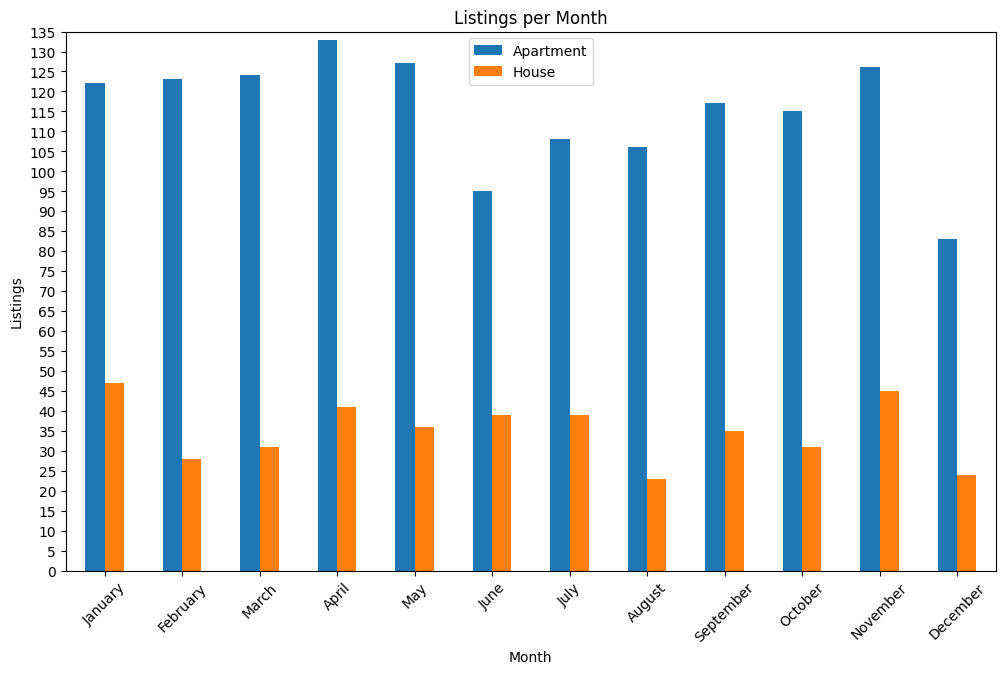

In [250]:
month_type = dataset.groupby(["Month","Type"]).size().unstack()
month_type = month_type.loc[month_order]
month_type.plot(figsize= (12,7), kind= "bar")
plt.ylim(0,135)
plt.yticks(range(0,140,5))
plt.ylabel("Listings")
plt.xticks(rotation=45)
plt.title("Listings per Month")
plt.legend()
plt.show()

---
#### **2. Median Rental Price by Postcode**

This visualization examines how rental prices vary across different **postcodes** and property **types**. The dataset is grouped by **Postcode** and **Type**, and the **median price** is calculated for each group. The use of the median helps reduce the impact of extreme values or outliers in the dataset.

The data is then reshaped using `unstack()` so that each property type can be displayed separately within the same chart. A predefined `postcode_order` is applied to ensure the postcodes are displayed in a logical sequence.

A **bar chart** is used to compare median rental prices across postcodes, with clear axis labels and formatting applied to improve readability. This visualization highlights differences in rental costs between areas and allows for comparison between property types within each postcode.

A clear pattern emerges, showing that **houses are consistently more expensive than apartments** in every postcode.

Apartment prices are relatively stable, generally ranging between **€1,300 and €2,300**, while house prices are significantly higher, typically falling between **€3,000 and €5,500**. This highlights the substantial price premium associated with renting houses compared to apartments.

There is also a noticeable **location-based trend**. Central postcodes such as **Dublin 2, Dublin 4, and Dublin 6** tend to have higher rental prices, particularly for houses, reflecting their desirability and proximity to key urban amenities. In contrast, more peripheral areas such as **Dublin 10, Dublin 11, and Dublin 22** show comparatively lower median prices.

The gap between apartment and house prices varies across postcodes but remains consistently large, indicating that **property type is a major driver of rental price differences**.

Overall, the chart demonstrates that:
- Houses command significantly higher rental prices than apartments  
- Central Dublin postcodes tend to be more expensive  
- Property type and location both play a key role in determining rental prices  

These findings reinforce the importance of considering both **postcode and property type** when analysing rental price patterns.

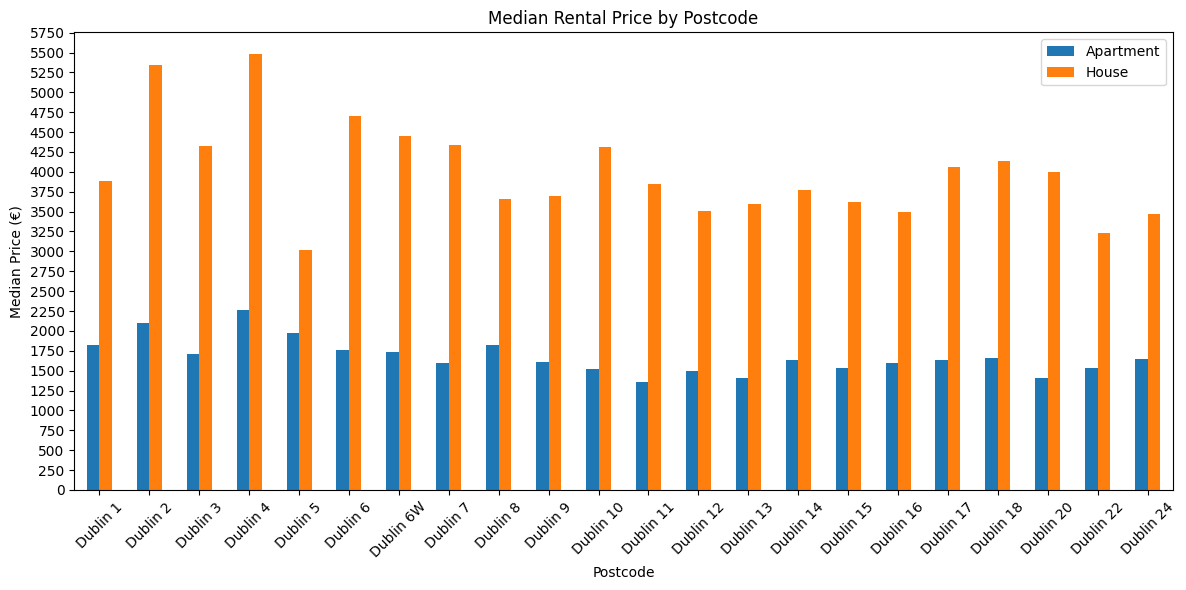

In [251]:
price_postcode = dataset.groupby(["Postcode", "Type"])["Price"].median().unstack()

price_postcode = price_postcode.loc[postcode_order]

price_postcode.plot(kind="bar",figsize=(12,6))

plt.xlabel("Postcode")
plt.ylabel("Median Price (€)")
plt.yticks(range(0,6000,250))
plt.title("Median Rental Price by Postcode")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

plt.show()

### **Discussion**
#### **a) Challenges Faced**

Several challenges were encountered during the scraping and data cleaning process. One of the main issues was **inconsistency in the raw data format**, particularly with text values. For example, some entries contained variations in formatting such as extra spaces, abbreviations, or hyphenation differences, which required additional cleaning and standardisation.

Another challenge was the **mismatch between Location and Postcode data**. Not all listings had corresponding postcode values, and certain areas such as North County Dublin and South County Dublin did not contain postcode information at all. This made it difficult to maintain consistency across location-based fields and required separating and removing incomplete records from the main dataset.

These inconsistencies meant that extra preprocessing steps were necessary to ensure the dataset was clean, uniform, and suitable for analysis.

---

#### **b) Key Insights**

The analysis revealed several patterns in the Dublin rental market. One key finding was that **location has a strong impact on rental prices**, with certain areas consistently showing higher median rents than others.

Property characteristics also influenced pricing. For example, **properties with more bedrooms generally had higher rental prices**, and houses tended to be more expensive than apartments. Features such as **gardens and parking** were also associated with higher prices, although the relationship was not always consistent across all locations.

The analysis also showed that **rental listings vary across months**, indicating possible seasonal trends in the housing market. Overall, the dataset provided useful insights into how different factors contribute to rental pricing.

---

#### **c) Further Work**

There are several opportunities for further analysis on this dataset. One possible extension would be to apply more advanced **machine learning models** to better predict Garden and Parking fields.

Another area for improvement would be to incorporate **external data sources**, such as geographic coordinates, to enhance location-based analysis. This could allow for more detailed spatial visualisations, such as maps.

Additionally, further work could explore **time-series analysis** to better understand seasonal trends in rental listings. Improving the data quality, particularly for missing values such as postcodes, would also enhance the reliability of future analyses.